# 01 — Exploracion visual del CPI Global

Primera inspeccion visual de la tasa de inflacion global mensual.

**Fuente:** World Bank hcpi_m — mediana interanual de 186 paises (replica HCPI_GLOBAL_MED).

**Nota:** `cpi_global_rate` ya es una tasa interanual (YoY %) calculada sobre indices
nacionales y agregada como mediana transversal. No es un indice en nivel.

**Entrada:** `data/processed/cpi_global_monthly.parquet`


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

NOTEBOOK_DIR = Path("C:/Users/usuario/OneDrive/Documentos/GitHub/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END, DATE_VAL_END, FREQ

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


## 1. Carga de datos

In [2]:
DATA_PATH = ROOT / "data" / "processed" / "cpi_global_monthly.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Rango: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()


Rango: 2002-01-01 -> 2024-12-01
Shape: (276, 1)
Columnas: ['cpi_global_rate']


,cpi_global_rate
date,
2002-01-01,3.348546
2002-02-01,3.432725
2002-03-01,3.255520
2002-04-01,3.260650
2002-05-01,2.979734


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
cpi_global_rate,276.0,3.441554,1.859766,0.799304,2.223008,2.933433,3.991994,9.639495


In [4]:
# Verificar frecuencia y gaps
expected = pd.date_range(df.index.min(), df.index.max(), freq="MS")
missing = expected.difference(df.index)
print(f"Meses esperados: {len(expected)}")
print(f"Meses presentes: {len(df)}")
print(f"Gaps: {len(missing)}")
if len(missing) > 0:
    print("Fechas faltantes:", missing.tolist())


Meses esperados: 276
Meses presentes: 276
Gaps: 0


## 2. Serie completa — Tasa de inflacion global (YoY %)

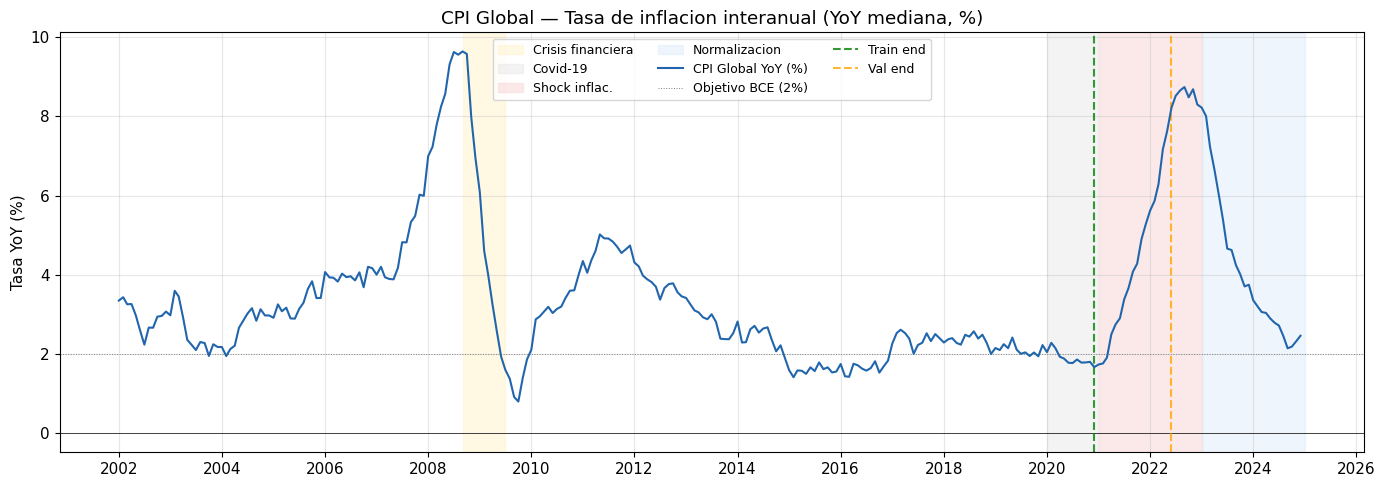

In [5]:
y = df["cpi_global_rate"]

fig, ax = plt.subplots()

# Shading subperiodos
SHADING = [
    ("Crisis financiera", "2008-09-01", "2009-06-30", "#fff3cd", 0.55),
    ("Covid-19",          "2020-01-01", "2020-12-31", "#e8e8e8", 0.50),
    ("Shock inflac.",     "2021-01-01", "2022-12-31", "#f8d7d7", 0.55),
    ("Normalizacion",     "2023-01-01", "2024-12-31", "#d7e8f8", 0.40),
]
for label, s, e, color, alpha in SHADING:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=color, alpha=alpha,
               zorder=0, label=label)

ax.plot(y.index, y.values, linewidth=1.5, color="#2166ac", zorder=3, label="CPI Global YoY (%)")
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(2, color="grey", linewidth=0.7, linestyle=":", label="Objetivo BCE (2%)")

# Train/test lines
for label, date, color in [
    ("Train end", DATE_TRAIN_END, "green"),
    ("Val end",   DATE_VAL_END,   "orange"),
]:
    ax.axvline(pd.Timestamp(date), color=color, linestyle="--", alpha=0.8, label=label)

ax.set_title("CPI Global — Tasa de inflacion interanual (YoY mediana, %)")
ax.set_ylabel("Tasa YoY (%)")
ax.legend(fontsize=9, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


## 3. Primera diferencia de la tasa (variacion mes a mes)

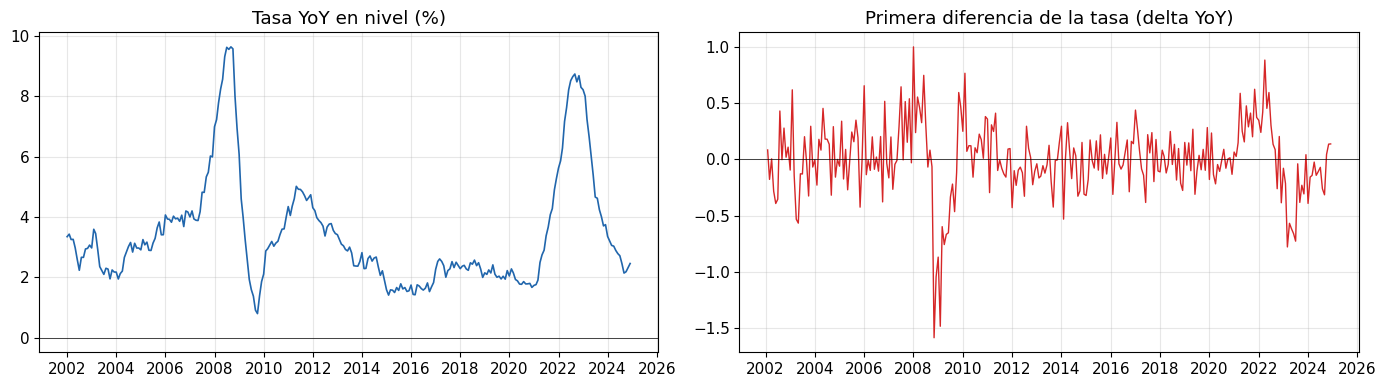

In [6]:
y_diff1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, y.values, linewidth=1.2, color="#2166ac")
axes[0].set_title("Tasa YoY en nivel (%)")
axes[0].axhline(0, color="black", linewidth=0.5)

axes[1].plot(y_diff1.index, y_diff1.values, linewidth=1.0, color="#d62728")
axes[1].set_title("Primera diferencia de la tasa (delta YoY)")
axes[1].axhline(0, color="black", linewidth=0.5)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


## 4. Distribucion mensual (box plot)

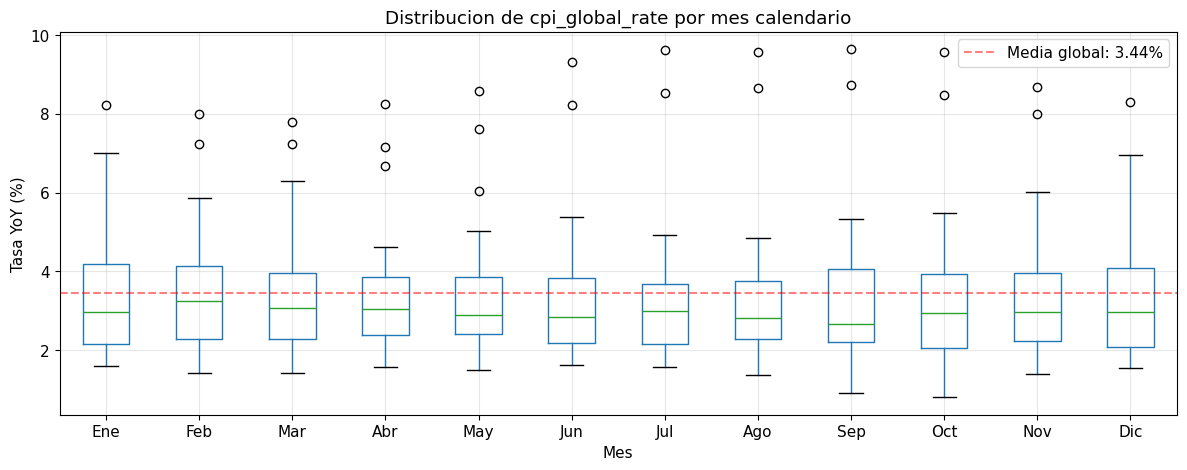

In [7]:
monthly_df = pd.DataFrame({
    "month": y.index.month,
    "rate": y.values,
})

fig, ax = plt.subplots(figsize=(12, 5))
monthly_df.boxplot(column="rate", by="month", ax=ax)
months = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
ax.set_xticklabels(months)
ax.set_title("Distribucion de cpi_global_rate por mes calendario")
ax.set_xlabel("Mes")
ax.set_ylabel("Tasa YoY (%)")
ax.axhline(y.mean(), color="red", linestyle="--", alpha=0.5, label=f"Media global: {y.mean():.2f}%")
ax.legend()
plt.suptitle("")
plt.tight_layout()
plt.show()


## 5. Splits train / val / test

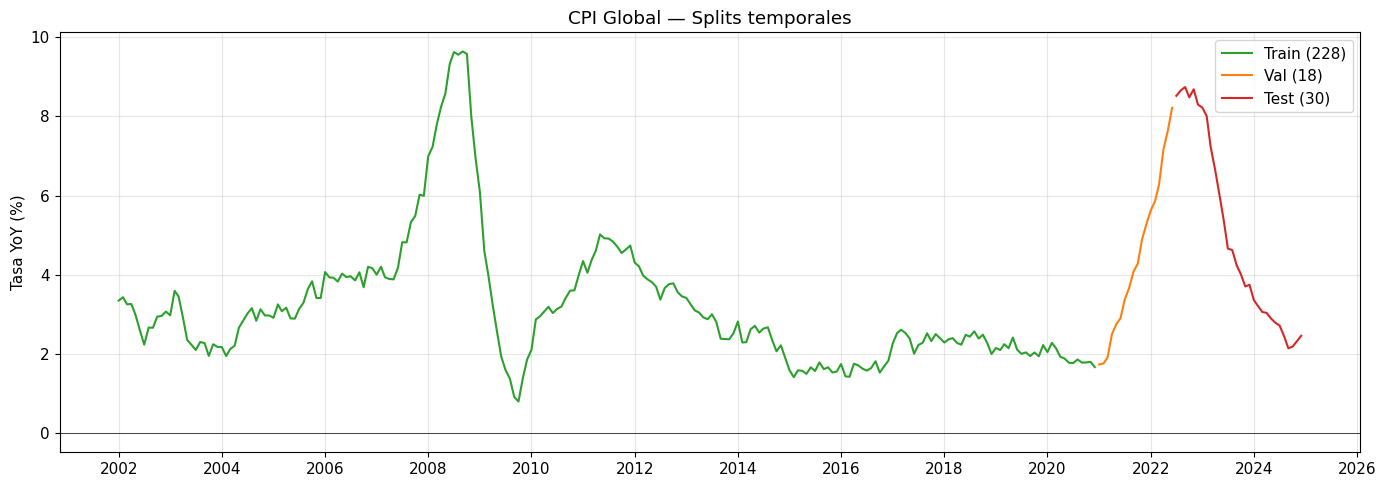

Train: 2002-01-01 -> 2020-12-01 (228 meses)
Val:   2021-01-01 -> 2022-06-01 (18 meses)
Test:  2022-07-01 -> 2024-12-01 (30 meses)


In [8]:
train = df.loc[:DATE_TRAIN_END]
val   = df.loc[DATE_TRAIN_END:DATE_VAL_END].iloc[1:]
test  = df.loc[DATE_VAL_END:].iloc[1:]

fig, ax = plt.subplots()
ax.plot(train.index, train["cpi_global_rate"], label=f"Train ({len(train)})", color="#2ca02c", linewidth=1.5)
ax.plot(val.index,   val["cpi_global_rate"],   label=f"Val ({len(val)})",     color="#ff7f0e", linewidth=1.5)
ax.plot(test.index,  test["cpi_global_rate"],  label=f"Test ({len(test)})",   color="#d62728", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("CPI Global — Splits temporales")
ax.set_ylabel("Tasa YoY (%)")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} meses)")
print(f"Val:   {val.index.min().date()} -> {val.index.max().date()} ({len(val)} meses)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} meses)")


## 6. Resumen

In [9]:
print("="*60)
print("RESUMEN EXPLORACION CPI GLOBAL")
print("="*60)
print(f"Rango temporal:  {df.index.min().date()} -> {df.index.max().date()}")
print(f"Total meses:     {len(df)}")
print(f"Frecuencia:      Mensual (MS)")
print(f"Gaps:            {len(missing)}")
print(f"NaN:             {df['cpi_global_rate'].isna().sum()}")
print(f"Media:           {y.mean():.4f} %")
print(f"Mediana:         {y.median():.4f} %")
print(f"Std:             {y.std():.4f} %")
print(f"Min:             {y.min():.4f} %  ({y.idxmin().date()})")
print(f"Max:             {y.max():.4f} %  ({y.idxmax().date()})")
print("="*60)
print()
print("Nota metodologica:")
print("  cpi_global_rate = mediana de tasas YoY de 186 paises (sin ponderacion PIB)")
print("  Difiere ~0.26 pp de media del HCPI_GLOBAL_MED anual del World Bank.")
print("  Ver 01_etl/01_ingest_cpi_global.py para detalles.")


RESUMEN EXPLORACION CPI GLOBAL
Rango temporal:  2002-01-01 -> 2024-12-01
Total meses:     276
Frecuencia:      Mensual (MS)
Gaps:            0
NaN:             0
Media:           3.4416 %
Mediana:         2.9334 %
Std:             1.8598 %
Min:             0.7993 %  (2009-10-01)
Max:             9.6395 %  (2008-09-01)

Nota metodologica:
  cpi_global_rate = mediana de tasas YoY de 186 paises (sin ponderacion PIB)
  Difiere ~0.26 pp de media del HCPI_GLOBAL_MED anual del World Bank.
  Ver 01_etl/01_ingest_cpi_global.py para detalles.
